# Practice 11 — Object Detection and Segmentation

Two tasks that answer *where*, not only *what*.

| Task | Output per object | Numbers per object |
|:---|:---|:---|
| Classification | one label for the whole image | 1 class index |
| Object detection | one axis-aligned box | 4 coordinates + class + confidence |
| Instance segmentation | one per-pixel mask | a mask the size of the image + class + confidence |

Nothing is trained here.
The weights arrive pretrained on the 80 COCO classes, and this notebook reads what they produce.

---
## Step 0. Setup

`ultralytics` provides the YOLO models and their inference API.
Passing a path to `YOLO(...)` downloads the weights to that path instead of the working directory.

In [1]:
import subprocess
import sys

try:
    import ultralytics
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'], check=True)
    import ultralytics

print(f'ultralytics {ultralytics.__version__}')

ultralytics 8.4.120


In [2]:
import urllib.request
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from ultralytics import YOLO

np.random.seed(42)
torch.manual_seed(42)

# every file this notebook writes goes under one of these two folders
BUILD = Path('build')
DATA = Path('data')
BUILD.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device : {device}')

device : cuda


image shape : (1380, 2070, 3)   height, width, channels


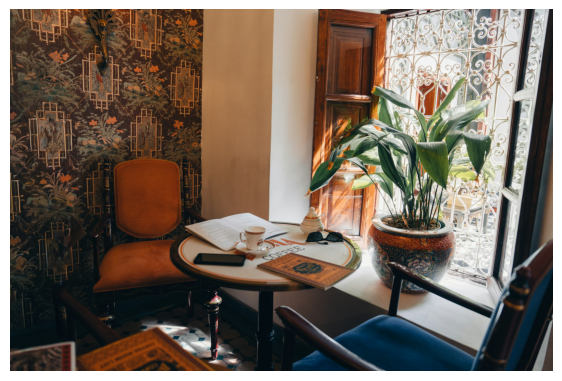

In [3]:
image_path = DATA / 'sample.jpg'
if not image_path.exists():
    urllib.request.urlretrieve(
        'https://images.unsplash.com/photo-1760681557777-bfac1f18cf90'
        '?ixlib=rb-4.1.0&auto=format&fit=crop&q=80&w=2070', image_path)

second_image_path = DATA / 'bus.jpg'
if not second_image_path.exists():
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', second_image_path)

image = np.array(Image.open(image_path).convert('RGB'))
print(f'image shape : {image.shape}   height, width, channels')

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.axis('off')
plt.show()

---
## Step 1. Running the Detector

`yolo11n` is the smallest YOLO11 model and already knows the 80 COCO classes.
`conf=0.25` discards detections the model is less than 25 percent confident about.

One call returns a list with one `Results` object per input image.

In [4]:
detection_model = YOLO(str(BUILD / 'yolo11n.pt'))
detection_results = detection_model.predict(source=str(image_path), conf=0.25, verbose=False)

print(f'results returned : {len(detection_results)}   one per input image')

detection_result = detection_results[0]
print(f'objects found    : {len(detection_result.boxes)}')
print(f'orig_shape       : {detection_result.orig_shape}')

results returned : 1   one per input image
objects found    : 6
orig_shape       : (1380, 2070)


---
## Step 2. What Is Inside `result.boxes`

Every attribute below has one row per detected object.

| Attribute | Shape | Meaning |
|:---|:---|:---|
| `boxes.xyxy` | (N, 4) | corners in pixels, $(x_1, y_1, x_2, y_2)$ |
| `boxes.xywhn` | (N, 4) | centre and size, divided by image size |
| `boxes.conf` | (N,) | confidence |
| `boxes.cls` | (N,) | class index, a float that indexes `result.names` |

In [5]:
print(f'boxes.xyxy  : {tuple(detection_result.boxes.xyxy.shape)}')
print(f'boxes.xywhn : {tuple(detection_result.boxes.xywhn.shape)}')
print(f'boxes.conf  : {tuple(detection_result.boxes.conf.shape)}')
print(f'boxes.cls   : {tuple(detection_result.boxes.cls.shape)}')
print(f'names       : {len(detection_result.names)} class names')
print()

for index in range(len(detection_result.boxes)):
    class_index = int(detection_result.boxes.cls[index])
    confidence = float(detection_result.boxes.conf[index])
    x1, y1, x2, y2 = detection_result.boxes.xyxy[index].cpu().numpy()
    print(f'{detection_result.names[class_index]:<14s} conf={confidence:.3f}  '
          f'x1={x1:7.1f} y1={y1:7.1f} x2={x2:7.1f} y2={y2:7.1f}')

boxes.xyxy  : (6, 4)
boxes.xywhn : (6, 4)
boxes.conf  : (6,)
boxes.cls   : (6,)
names       : 80 class names

chair          conf=0.833  x1= 1016.6 y1=  872.2 x2= 2068.9 y2= 1366.0
potted plant   conf=0.804  x1= 1185.8 y1=  249.7 x2= 1851.4 y2= 1067.3
cup            conf=0.766  x1=  887.0 y1=  825.0 x2=  975.6 y2=  918.5
chair          conf=0.719  x1=  316.7 y1=  567.5 x2=  716.0 y2= 1177.8
dining table   conf=0.565  x1=  630.5 y1=  771.6 x2= 1357.6 y2= 1364.1
chair          conf=0.405  x1=  162.1 y1= 1039.8 x2=  750.2 y2= 1368.2


The two coordinate systems hold the same box.

$$x_1 = (c_x - w/2)\,W, \quad y_1 = (c_y - h/2)\,H, \quad
x_2 = (c_x + w/2)\,W, \quad y_2 = (c_y + h/2)\,H$$

Normalized coordinates survive a resize of the image, pixel coordinates do not.

In [6]:
image_height, image_width = detection_result.orig_shape

center_x, center_y, box_width, box_height = detection_result.boxes.xywhn[0].cpu().numpy()
x1_from_normalized = (center_x - box_width / 2) * image_width
y1_from_normalized = (center_y - box_height / 2) * image_height
x2_from_normalized = (center_x + box_width / 2) * image_width
y2_from_normalized = (center_y + box_height / 2) * image_height

print('first box, two ways of writing the same rectangle')
print(f'xyxy               : {detection_result.boxes.xyxy[0].cpu().numpy()}')
print(f'xywhn -> pixels    : [{x1_from_normalized:.4f} {y1_from_normalized:.4f} '
      f'{x2_from_normalized:.4f} {y2_from_normalized:.4f}]')

first box, two ways of writing the same rectangle
xyxy               : [     1016.6      872.21      2068.9        1366]
xywhn -> pixels    : [1016.6174 872.2095 2068.9238 1366.0220]


The two lines agree to the last printed digit.
Anything that resizes the image changes the first line and leaves the second one valid.

---
## Step 3. Drawing the Boxes

`result.plot()` returns an annotated copy of the image in **BGR** order, so the channels are reversed
before matplotlib sees it.

Drawing the same boxes by hand is what makes the numbers above concrete.

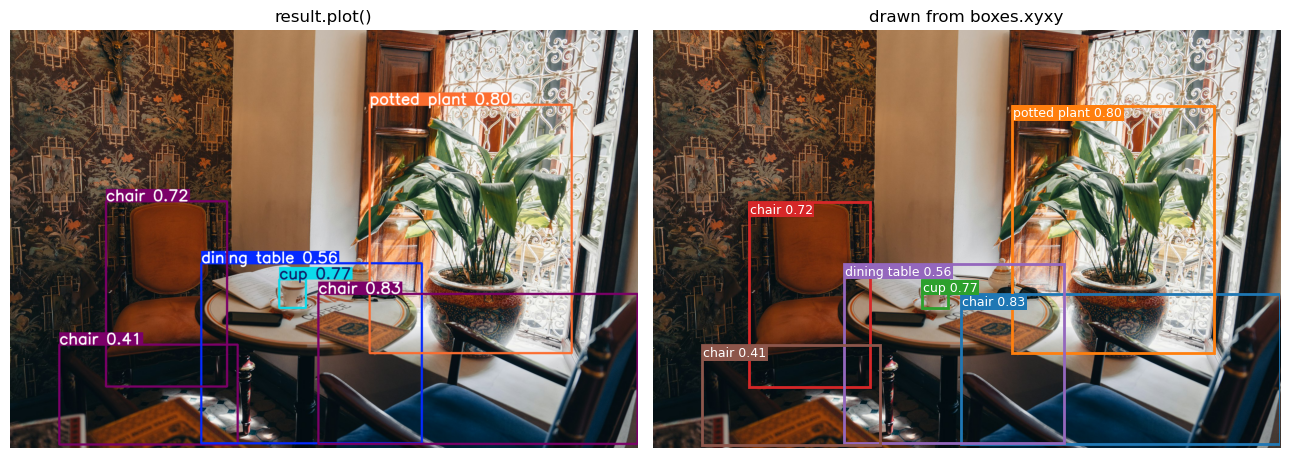

In [7]:
annotated_image = detection_result.plot()[:, :, ::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(annotated_image)
axes[0].set_title('result.plot()')
axes[0].axis('off')

axes[1].imshow(image)
for index in range(len(detection_result.boxes)):
    class_index = int(detection_result.boxes.cls[index])
    confidence = float(detection_result.boxes.conf[index])
    x1, y1, x2, y2 = detection_result.boxes.xyxy[index].cpu().numpy()
    instance_color = plt.cm.tab10(index % 10)
    axes[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=instance_color, linewidth=2))
    # the label sits inside the top edge, so a box touching y=0 keeps its text on the image
    axes[1].text(x1 + 4, y1 + 4, f'{detection_result.names[class_index]} {confidence:.2f}',
                 color='white', fontsize=9, va='top', ha='left', clip_on=True,
                 bbox=dict(facecolor=instance_color, edgecolor='none', pad=1))
axes[1].set_title('drawn from boxes.xyxy')
axes[1].axis('off')

plt.tight_layout(); plt.show()

The two panels carry the same rectangles, drawn by two different pieces of code.
`plot()` is convenient; the loop on the right is what the coordinates mean.

---
## Step 4. The Confidence Threshold

`conf` is the only thing that changes between the two calls below.
Everything the model computed stays the same; the threshold decides what survives.

In [8]:
low_threshold_result = detection_model.predict(source=str(image_path), conf=0.25, verbose=False)[0]
high_threshold_result = detection_model.predict(source=str(image_path), conf=0.50, verbose=False)[0]

low_threshold_names = []
for index in range(len(low_threshold_result.boxes)):
    low_threshold_names.append(low_threshold_result.names[int(low_threshold_result.boxes.cls[index])])

high_threshold_names = []
for index in range(len(high_threshold_result.boxes)):
    high_threshold_names.append(high_threshold_result.names[int(high_threshold_result.boxes.cls[index])])

print(f'conf=0.25 : {len(low_threshold_names):2d} objects  ' + ', '.join(low_threshold_names))
print(f'conf=0.50 : {len(high_threshold_names):2d} objects  ' + ', '.join(high_threshold_names))

conf=0.25 :  6 objects  chair, potted plant, cup, chair, dining table, chair
conf=0.50 :  5 objects  chair, potted plant, cup, chair, dining table


The list shortens from the bottom.
`conf` does not change what the model computed, only which of its answers are shown.

---
## Step 5. The Segmentation Model

A segmentation model returns everything the detector returns, plus one mask per object.

| Attribute | What it holds |
|:---|:---|
| `masks.data` | a binary mask per object, as a grid of 0 and 1 |
| `masks.xy` | the outline of that mask, in original image pixels |

In [9]:
segmentation_model = YOLO(str(BUILD / 'yolo11n-seg.pt'))
segmentation_result = segmentation_model.predict(source=str(image_path), conf=0.25, verbose=False)[0]

print(f'objects found : {len(segmentation_result.boxes)}')
print(f'boxes.xyxy    : {tuple(segmentation_result.boxes.xyxy.shape)}')
print(f'masks.data    : {tuple(segmentation_result.masks.data.shape)}')
print(f'orig_shape    : {segmentation_result.orig_shape}')
print()

for index in range(len(segmentation_result.boxes)):
    class_index = int(segmentation_result.boxes.cls[index])
    confidence = float(segmentation_result.boxes.conf[index])
    outline = segmentation_result.masks.xy[index]
    print(f'{segmentation_result.names[class_index]:<14s} conf={confidence:.3f}  '
          f'masks.xy[{index}] = {outline.shape} outline points')

objects found : 7
boxes.xyxy    : (7, 4)
masks.data    : (7, 448, 640)
orig_shape    : (1380, 2070)

chair          conf=0.882  masks.xy[0] = (354, 2) outline points
cup            conf=0.850  masks.xy[1] = (30, 2) outline points
potted plant   conf=0.834  masks.xy[2] = (458, 2) outline points
chair          conf=0.721  masks.xy[3] = (245, 2) outline points
remote         conf=0.291  masks.xy[4] = (36, 2) outline points
chair          conf=0.280  masks.xy[5] = (173, 2) outline points
dining table   conf=0.268  masks.xy[6] = (498, 2) outline points


The mask grid above is **not** the size of the image.
It comes back at the resolution the model ran at, which is what `predict` resized the image to.

`retina_masks=True` asks for the masks at the original image size instead.

In [10]:
retina_result = segmentation_model.predict(source=str(image_path), conf=0.25,
                                           retina_masks=True, verbose=False)[0]

print(f'orig_shape             : {segmentation_result.orig_shape}')
print(f'masks.data  default    : {tuple(segmentation_result.masks.data.shape)}')
print(f'masks.data  retina     : {tuple(retina_result.masks.data.shape)}')
print(f'masks.xy[0] default    : {segmentation_result.masks.xy[0].shape}')
print(f'masks.xy[0] retina     : {retina_result.masks.xy[0].shape}')

orig_shape             : (1380, 2070)
masks.data  default    : (7, 448, 640)
masks.data  retina     : (7, 1380, 2070)
masks.xy[0] default    : (354, 2)
masks.xy[0] retina     : (1088, 2)


The outline changes length with the mask resolution.
That is the clearest sign of what the model actually predicts: a grid of pixels, from which an outline
is traced afterwards.

One mask comes back per object, not one per class.
Two chairs in the list above carry two separate masks, and that count is part of the answer.

| Task | One output covers |
|:---|:---|
| Semantic segmentation | every pixel of a class, as a single region |
| Instance segmentation | every pixel of one object, one mask per object |

The models in this notebook do the second.

---
## Step 6. Drawing the Masks

Each mask is a grid of 0 and 1 at the size of the image, so it can be laid straight on top of it.
The third panel below is one such grid on its own, and `result.plot()` stacks all seven of them.

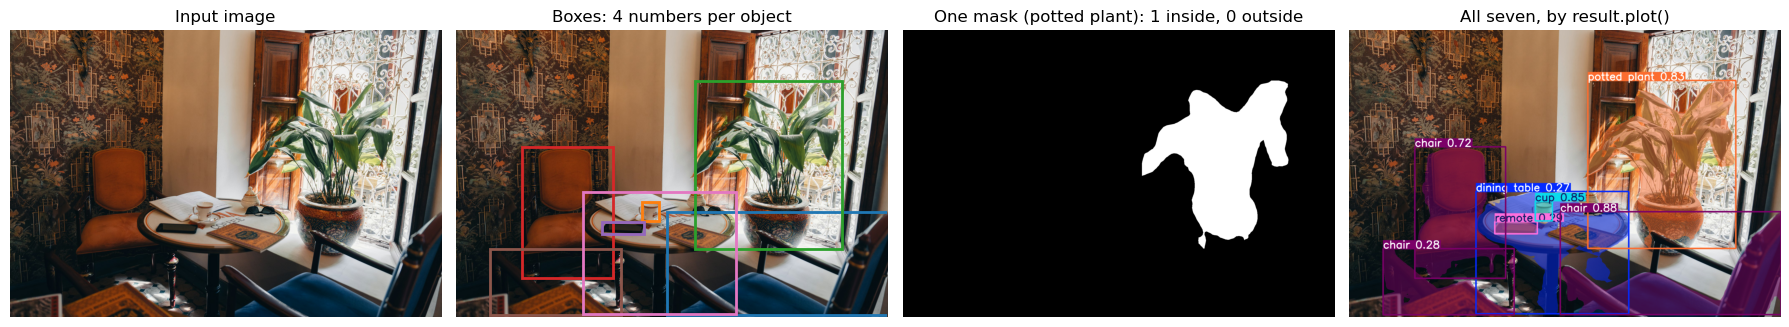

In [11]:
mask_index = 2
mask_class = retina_result.names[int(retina_result.boxes.cls[mask_index])]
one_mask = retina_result.masks.data[mask_index].cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(image)
axes[0].set_title('Input image')
axes[0].axis('off')

axes[1].imshow(image)
for index in range(len(retina_result.boxes)):
    x1, y1, x2, y2 = retina_result.boxes.xyxy[index].cpu().numpy()
    axes[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                                edgecolor=plt.cm.tab10(index % 10), linewidth=2))
axes[1].set_title('Boxes: 4 numbers per object')
axes[1].axis('off')

axes[2].imshow(one_mask, cmap='gray')
axes[2].set_title(f'One mask ({mask_class}): 1 inside, 0 outside')
axes[2].axis('off')

axes[3].imshow(retina_result.plot()[:, :, ::-1])
axes[3].set_title('All seven, by result.plot()')
axes[3].axis('off')

plt.tight_layout(); plt.show()

The white shape in the third panel is one object, and every pixel outside it is 0.
A box says where an object is; a mask says which pixels are the object.
Overlapping chairs still get separate colours, because each mask belongs to one instance.

---
## Step 7. What the Mask Buys You

A mask can be counted; a box cannot.
Dividing the mask area by the box area says how much of the box the object actually fills.

In [12]:
print('object          mask pixels   box pixels   fill')
for index in range(len(retina_result.boxes)):
    class_index = int(retina_result.boxes.cls[index])
    x1, y1, x2, y2 = retina_result.boxes.xyxy[index].cpu().numpy()
    box_pixels = (x2 - x1) * (y2 - y1)
    mask_pixels = float(retina_result.masks.data[index].cpu().numpy().sum())
    print(f'{retina_result.names[class_index]:<14s} {mask_pixels:11.0f} {box_pixels:12.0f}   '
          f'{mask_pixels / box_pixels:.3f}')

object          mask pixels   box pixels   fill
chair               198955       520727   0.382
cup                   6463         7678   0.842
potted plant        279479       570657   0.490
chair               169875       273761   0.621
remote               10375        11729   0.885
chair                99260       198922   0.499
dining table        165225       429334   0.385


Compact objects fill most of their box, and wide or hollow ones do not.
A number this simple already separates the cases where a box is a fair summary from the cases where it
is mostly background.

---
## Step 8. The Same Two Calls on Another Image

Nothing about the code changes when the picture does.

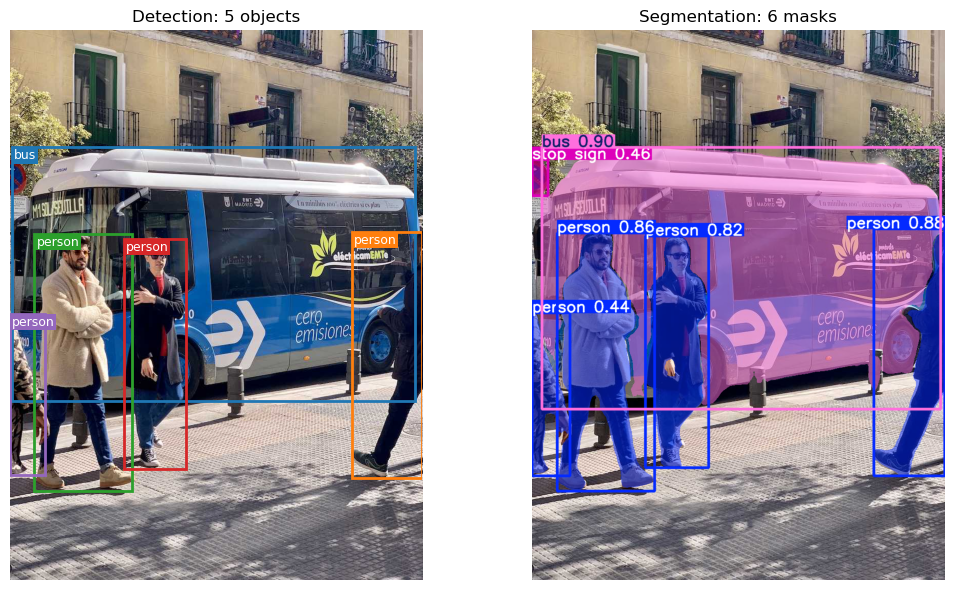

In [13]:
second_image = np.array(Image.open(second_image_path).convert('RGB'))
second_detection = detection_model.predict(source=str(second_image_path), conf=0.25, verbose=False)[0]
second_segmentation = segmentation_model.predict(source=str(second_image_path), conf=0.25,
                                                 retina_masks=True, verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 6))

axes[0].imshow(second_image)
for index in range(len(second_detection.boxes)):
    class_index = int(second_detection.boxes.cls[index])
    x1, y1, x2, y2 = second_detection.boxes.xyxy[index].cpu().numpy()
    instance_color = plt.cm.tab10(index % 10)
    axes[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=instance_color, linewidth=2))
    axes[0].text(x1 + 4, y1 + 4, second_detection.names[class_index],
                 color='white', fontsize=9, va='top', ha='left', clip_on=True,
                 bbox=dict(facecolor=instance_color, edgecolor='none', pad=1))
axes[0].set_title(f'Detection: {len(second_detection.boxes)} objects')
axes[0].axis('off')

axes[1].imshow(second_segmentation.plot()[:, :, ::-1])
axes[1].set_title(f'Segmentation: {len(second_segmentation.boxes)} masks')
axes[1].axis('off')

plt.tight_layout(); plt.show()

---
## Summary

- A detection result holds one row per object in `boxes.xyxy`, `boxes.conf` and `boxes.cls`, and
  `boxes.xywhn` is the same rectangle divided by the image size.
- A segmentation result adds `masks.data`, whose resolution follows the model input unless
  `retina_masks=True` asks for the original size.
- Mask pixels can be counted, and their share of the box says how much of it the object fills.

---
## Exercises

1. Raise `conf` to 0.7 and rerun the detection listing.
   Which objects disappear first, and what were their confidences?
2. Print `boxes.xywhn` for every object and check that no value falls outside 0 to 1.
3. Draw only the object with the largest mask area, using the fill numbers from Step 7.

In [14]:
# Write your code here